In [1]:
import glob, os, pandas as pd, gc

folder = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\store_name_1525\data"
save_path = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest"

# 1. dfs 로드
dfs = {}
for file in glob.glob(f"{folder}\\*.csv"):
    name = os.path.basename(file).replace(".csv", "")[-6:]
    dfs[f"df_{name}"] = pd.read_csv(file, low_memory=False)

# 2. df_all 생성
df_all = pd.concat([df.assign(period=name) for name, df in dfs.items()], ignore_index=True)
del dfs; gc.collect()

df_all = df_all[df_all["건물관리번호"].notna()]#건물관리번호 결측값 제거
df_all["위치ID"] = df_all["건물관리번호"].astype(str) + "_" + df_all["층정보"].astype(str) + "_" + df_all["호정보"].astype(str)

# 3. location_meta 저장
location_meta = df_all.groupby("위치ID").agg(
    위도=("위도", "first"), 경도=("경도", "first"),
    시군구명=("시군구명", "first"), 행정동명=("행정동명", "first"),
    건물관리번호=("건물관리번호", "first"), 도로명주소=("도로명주소", "first")
).reset_index()
location_meta.to_csv(f"{save_path}\\location_meta.csv", index=False)
del location_meta; gc.collect()
print("✅ location_meta 저장 완료!")

# 4. pivot_df 저장
pivot_df = df_all.groupby(["위치ID", "period"])["상가업소번호"].first().unstack("period")
pivot_df.to_csv(f"{save_path}\\pivot_df.csv")
del pivot_df; gc.collect()
print("✅ pivot_df 저장 완료!")

# 5. shop_history_raw 저장
shop_history_raw = df_all[["위치ID", "상가업소번호", "period", "상권업종소분류명", "시군구명", "행정동명"]].copy()
shop_history_raw.to_csv(f"{save_path}\\shop_history_raw.csv", index=False)
del df_all; gc.collect()
print("✅ shop_history_raw 저장 완료!")

✅ location_meta 저장 완료!
✅ pivot_df 저장 완료!
✅ shop_history_raw 저장 완료!


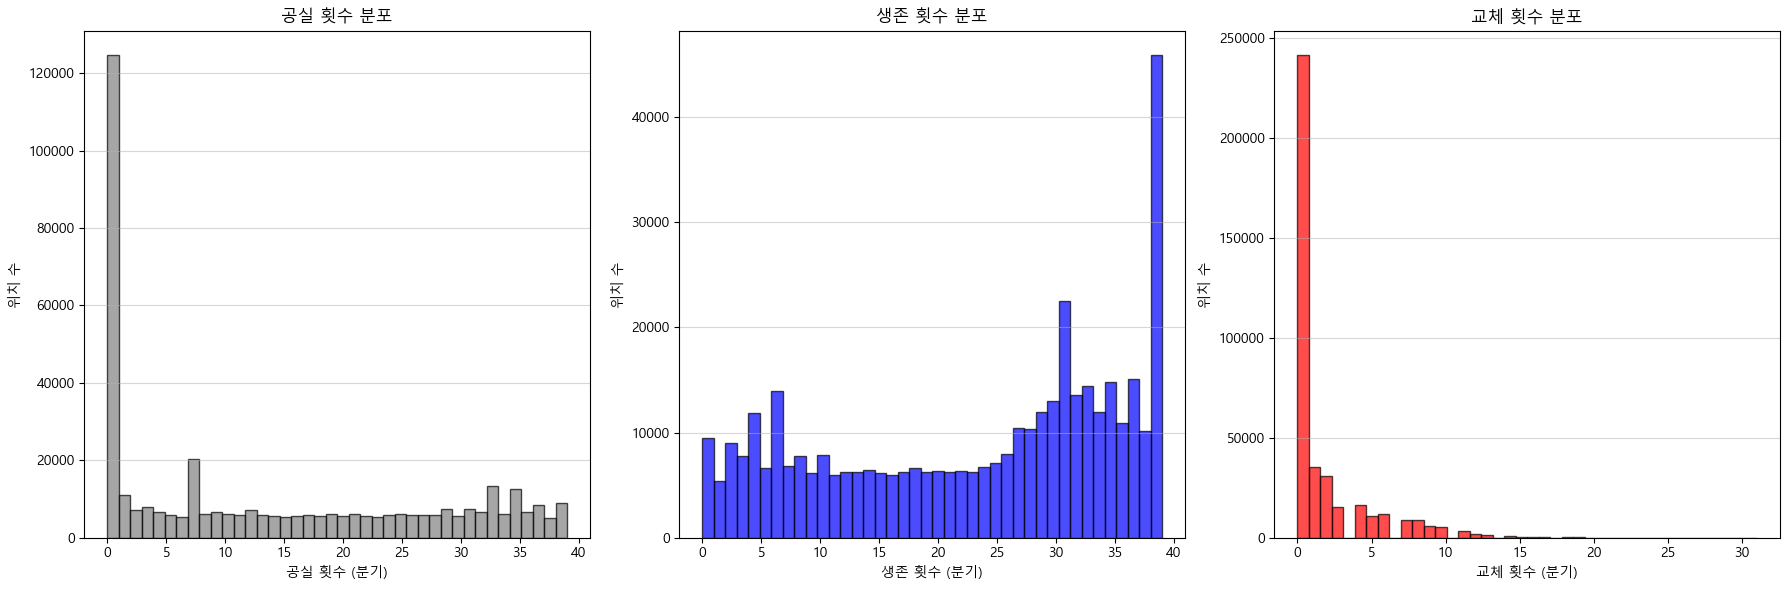

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Malgun Gothic')

save_path = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest"

# pivot_df 불러오기
pivot_df = pd.read_csv(f"{save_path}\\pivot_df.csv", index_col="위치ID")

# 지표 계산
cols = pivot_df.columns.tolist()

vacancy_count = pivot_df.isna().sum(axis=1)  # 공실 횟수
survival_count = (pivot_df == pivot_df.shift(axis=1)).sum(axis=1)  # 생존 횟수
replacement_count = ((pivot_df != pivot_df.shift(axis=1)) & pivot_df.notna() & pivot_df.shift(axis=1).notna()).sum(axis=1)  # 교체 횟수

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].hist(vacancy_count, bins=40, edgecolor='black', color='gray', alpha=0.7)
axes[0].set_title("공실 횟수 분포")
axes[0].set_xlabel("공실 횟수 (분기)")
axes[0].set_ylabel("위치 수")
axes[0].grid(axis='y', alpha=0.5)

axes[1].hist(survival_count, bins=40, edgecolor='black', color='blue', alpha=0.7)
axes[1].set_title("생존 횟수 분포")
axes[1].set_xlabel("생존 횟수 (분기)")
axes[1].set_ylabel("위치 수")
axes[1].grid(axis='y', alpha=0.5)

axes[2].hist(replacement_count, bins=40, edgecolor='black', color='red', alpha=0.7)
axes[2].set_title("교체 횟수 분포")
axes[2].set_xlabel("교체 횟수 (분기)")
axes[2].set_ylabel("위치 수")
axes[2].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

In [3]:
# 지표 데이터프레임으로 만들기
location_stats = pd.DataFrame({
    "공실횟수": vacancy_count,
    "생존횟수": survival_count,
    "교체횟수": replacement_count
})

# 기본 통계
print(location_stats.describe())

                공실횟수           생존횟수           교체횟수
count  400910.000000  400910.000000  400910.000000
mean       13.697433      23.336183       1.744179
std        13.534162      12.548299       3.056459
min         0.000000       0.000000       0.000000
25%         0.000000      12.000000       0.000000
50%         9.000000      27.000000       0.000000
75%        26.000000      34.000000       2.000000
max        39.000000      39.000000      31.000000


In [4]:
nan_locations = location_stats[location_stats.index.str.startswith("nan")]
print(f"건물관리번호 없는 위치 수: {len(nan_locations)}")
print(nan_locations)

건물관리번호 없는 위치 수: 0
Empty DataFrame
Columns: [공실횟수, 생존횟수, 교체횟수]
Index: []


In [4]:
import geopandas as gpd

sangkwon = gpd.read_file(r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\area\서울시 상권분석서비스(영역-상권).shp", encoding='utf-8')
print(sangkwon.columns.tolist())
print(sangkwon.crs)
print(sangkwon.head())

['TRDAR_SE_C', 'TRDAR_SE_1', 'TRDAR_CD', 'TRDAR_CD_N', 'XCNTS_VALU', 'YDNTS_VALU', 'SIGNGU_CD', 'SIGNGU_CD_', 'ADSTRD_CD', 'ADSTRD_CD_', 'RELM_AR', 'geometry']
EPSG:5181
  TRDAR_SE_C TRDAR_SE_1 TRDAR_CD         TRDAR_CD_N  XCNTS_VALU  YDNTS_VALU  \
0          A       골목상권  3110008    배화여자대학교(박노수미술관)    197093.0    453418.0   
1          U       관광특구  3001494         종로·청계 관광특구    199796.0    452274.0   
2          R       전통시장  3130021             신설종합시장    201854.0    452569.0   
3          R       전통시장  3130002  세종마을음식문화거리(금천교시장)    197423.0    453030.0   
4          R       전통시장  3130001               통인시장    197351.0    453449.0   

  SIGNGU_CD SIGNGU_CD_ ADSTRD_CD   ADSTRD_CD_   RELM_AR  \
0     11110        종로구  11110515        청운효자동  149264.0   
1     11110        종로구  11110615  종로1·2·3·4가동  653127.0   
2     11110        종로구  11110710         숭인2동    9800.0   
3     11110        종로구  11110530          사직동   49557.0   
4     11110        종로구  11110515        청운효자동   38280.0   



In [7]:
import pandas as pd
from shapely.geometry import Point

# location_meta 불러오기
location_meta = pd.read_csv(r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\location_meta.csv")

# GeoDataFrame으로 변환
location_gdf = gpd.GeoDataFrame(
    location_meta,
    geometry=gpd.points_from_xy(location_meta["경도"], location_meta["위도"]),
    crs="EPSG:4326"
)

# 좌표계 맞추기 (4326 → 5181)
location_gdf = location_gdf.to_crs("EPSG:5181")

# 공간조인 - 어느 상권 폴리곤 안에 있는지
joined = gpd.sjoin(location_gdf, sangkwon[["TRDAR_CD", "TRDAR_CD_N", "TRDAR_SE_1", "geometry"]], how="left", predicate="within")

print(joined.shape)
print(joined["TRDAR_CD"].isna().sum(), "개 위치가 상권 밖")
print(joined.head())

(410606, 12)
80361 개 위치가 상권 밖
                                위치ID         위도          경도 시군구명   행정동명  \
0    1111010100100010000030843_1_nan  37.590608  126.968670  종로구  청운효자동   
1    1111010100100030065030970_1_nan  37.592103  126.967073  종로구  청운효자동   
2    1111010100100030065030970_2_nan  37.592103  126.967073  종로구  청운효자동   
3  1111010100100040015031497_nan_nan  37.590130  126.967414  종로구  청운효자동   
4  1111010100100120003030970_nan_nan  37.589797  126.968252  종로구  청운효자동   

                      건물관리번호                    도로명주소               geometry  \
0  1111010100100010000030843  서울특별시 종로구 자하문로36길 16-14  POINT (197233 454561)   
1  1111010100100030065030970       서울특별시 종로구 창의문로 119  POINT (197092 454727)   
2  1111010100100030065030970       서울특별시 종로구 창의문로 119  POINT (197092 454727)   
3  1111010100100040015031497     서울특별시 종로구 자하문로36길 23  POINT (197122 454508)   
4  1111010100100120003030970   서울특별시 종로구 자하문로36길 11-4  POINT (197196 454471)   

   index_right TRDAR_CD TRDAR_CD_N TRD

In [8]:
# 상권 안/밖 비율
total = len(joined)
in_sangkwon = joined["TRDAR_CD"].notna().sum()
out_sangkwon = joined["TRDAR_CD"].isna().sum()

print(f"전체 위치: {total}")
print(f"상권 안: {in_sangkwon} ({in_sangkwon/total*100:.1f}%)")
print(f"상권 밖: {out_sangkwon} ({out_sangkwon/total*100:.1f}%)")

# 상권 안에 있는 것만 필터링
in_area = joined[joined["TRDAR_CD"].notna()].copy()
print(f"\n분석 대상 위치: {len(in_area)}")

전체 위치: 410606
상권 안: 330245 (80.4%)
상권 밖: 80361 (19.6%)

분석 대상 위치: 330245
